# Filter-Based Feature Selection

Applying filter-based feature selection techniques — duplicate column removal, variance threshold, correlation, ANOVA, and Chi-square — on the Human Activity Recognition (HAR) and Titanic datasets.

## Load Data + Baseline Model

Loading the HAR dataset and training a baseline Logistic Regression model before any feature selection, to compare against later.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold, f_classif, SelectKBest, chi2
from scipy.stats import chi2_contingency

df = pd.read_csv('data/har_train.csv').drop(columns='subject')
print(df.shape)
df.head()

(7352, 562)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


### Baseline: Logistic Regression (No Feature Selection)
Training on all original features first, to compare against after we apply filter-based selection.

In [18]:
X = df.drop('Activity', axis=1)
y = df['Activity']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(5881, 561)
(1471, 561)


In [19]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9809653297076818


## Technique 1: Removing Duplicate Columns

Some HAR features are exact duplicates of others (identical values across all rows) — these add no new information and can be safely removed.

In [20]:
def get_duplicate_columns(df):
    duplicate_columns = {}
    seen_columns = {}

    for column in df.columns:
        current_column = df[column]
        try:
            current_column_hash = current_column.values.tobytes()
        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_columns:
            if seen_columns[current_column_hash] in duplicate_columns:
                duplicate_columns[seen_columns[current_column_hash]].append(column)
            else:
                duplicate_columns[seen_columns[current_column_hash]] = [column]
        else:
            seen_columns[current_column_hash] = column

    return duplicate_columns

duplicate_columns = get_duplicate_columns(X_train)
duplicate_columns

{'tBodyAccMag-mean()': ['tBodyAccMag-sma()',
  'tGravityAccMag-mean()',
  'tGravityAccMag-sma()'],
 'tBodyAccMag-std()': ['tGravityAccMag-std()'],
 'tBodyAccMag-mad()': ['tGravityAccMag-mad()'],
 'tBodyAccMag-max()': ['tGravityAccMag-max()'],
 'tBodyAccMag-min()': ['tGravityAccMag-min()'],
 'tBodyAccMag-energy()': ['tGravityAccMag-energy()'],
 'tBodyAccMag-iqr()': ['tGravityAccMag-iqr()'],
 'tBodyAccMag-entropy()': ['tGravityAccMag-entropy()'],
 'tBodyAccMag-arCoeff()1': ['tGravityAccMag-arCoeff()1'],
 'tBodyAccMag-arCoeff()2': ['tGravityAccMag-arCoeff()2'],
 'tBodyAccMag-arCoeff()3': ['tGravityAccMag-arCoeff()3'],
 'tBodyAccMag-arCoeff()4': ['tGravityAccMag-arCoeff()4'],
 'tBodyAccJerkMag-mean()': ['tBodyAccJerkMag-sma()'],
 'tBodyGyroMag-mean()': ['tBodyGyroMag-sma()'],
 'tBodyGyroJerkMag-mean()': ['tBodyGyroJerkMag-sma()'],
 'fBodyAccMag-mean()': ['fBodyAccMag-sma()'],
 'fBodyBodyAccJerkMag-mean()': ['fBodyBodyAccJerkMag-sma()'],
 'fBodyBodyGyroMag-mean()': ['fBodyBodyGyroMag-sma()'

In [21]:
for one_list in duplicate_columns.values():
    X_train.drop(columns=one_list, inplace=True)
    X_test.drop(columns=one_list, inplace=True)

print(X_train.shape)
print(X_test.shape)

(5881, 540)
(1471, 540)


## Technique 2: Variance Threshold

Features with very low variance carry little information (they're nearly constant across samples) and can be dropped. We use a threshold of 0.05.

In [22]:
sel = VarianceThreshold(threshold=0.05)
sel.fit(X_train)

print("Features kept:", sum(sel.get_support()))

columns = X_train.columns[sel.get_support()]

X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

print(X_train.shape)
print(X_test.shape)

Features kept: 349
(5881, 349)
(1471, 349)


## Technique 3: Correlation-Based Removal

Highly correlated features (>0.95) carry redundant information — keeping both adds noise without adding predictive value. We visualize the correlation matrix, then drop one feature from each highly-correlated pair.

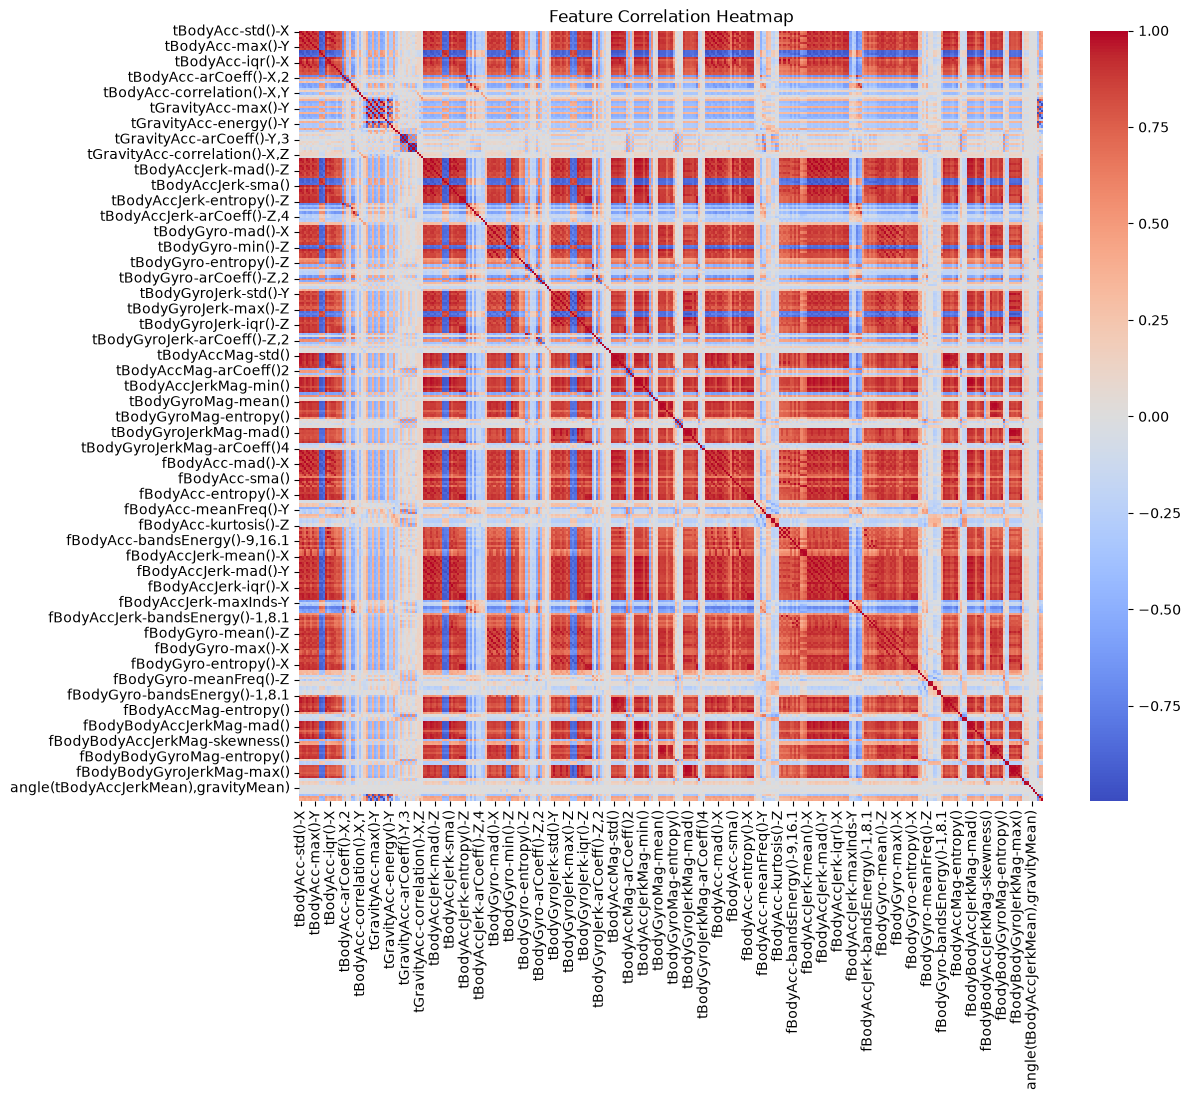

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
corr_matrix = X_train.corr()
columns = corr_matrix.columns

columns_to_drop = []

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if corr_matrix.loc[columns[i], columns[j]] > 0.95:
            columns_to_drop.append(columns[j])

columns_to_drop = set(columns_to_drop)
print("Columns to drop:", len(columns_to_drop))

X_train.drop(columns=columns_to_drop, inplace=True)
X_test.drop(columns=columns_to_drop, inplace=True)

print(X_train.shape)
print(X_test.shape)

Columns to drop: 197
(5881, 152)
(1471, 152)


## Technique 4: ANOVA (SelectKBest)

Using the ANOVA F-statistic to rank features by how well they separate the target classes, keeping only the top 100.

In [25]:
sel = SelectKBest(f_classif, k=100).fit(X_train, y_train)

columns = X_train.columns[sel.get_support()]
print(columns.tolist())

X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

print(X_train.shape)
print(X_test.shape)

['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-Y,Z', 'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z', 'tGravityAcc-sma()', 'tGravityAcc-energy()-Y', 'tGravityAcc-energy()-Z', 'tGravityAcc-entropy()-X', 'tGravityAcc-entropy()-Y', 'tGravityAcc-arCoeff()-Y,1', 'tGravityAcc-arCoeff()-Y,2', 'tGravityAcc-arCoeff()-Z,1', 'tGravityAcc-arCoeff()-Z,2', 'tGravityAcc-correlation()-Y,Z', 'tBodyAccJerk-std()-Z', 'tBodyAccJerk-min()-X', 'tBodyAccJerk-min()-Y', 'tBodyAccJerk-min()-Z', 'tBodyAccJerk-entropy()-X', 'tBodyAccJerk-arCoeff()-X,3', 'tBodyAccJerk-correlation()-X,Y', 'tBodyGyro-std()-X', 'tBodyGyro-std()-Y', 'tBodyGyro-std()-Z'

## Moment of Truth: Accuracy After Feature Selection

Comparing accuracy on 100 features (after all filter techniques) against the original baseline on 561 features.

In [26]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy (after feature selection):", accuracy)
print("Baseline accuracy (all features):", 0.9809653297076818)

Test accuracy (after feature selection): 0.9694085656016316
Baseline accuracy (all features): 0.9809653297076818


## Technique 5: Chi-Square Test (Titanic Dataset)

Chi-square tests whether a categorical feature is independent of the target — useful for categorical data, which ANOVA and correlation aren't suited for. Switching to the Titanic dataset since it has clear categorical features (Sex, Embarked, etc.).

In [27]:
titanic = pd.read_csv('data/titanic_train.csv')[['Pclass','Sex','SibSp','Parch','Embarked','Survived']]
titanic.head()

,Pclass,Sex,SibSp,Parch,Embarked,Survived
0,3,male,1,0,S,0
1,1,female,1,0,C,1
2,3,female,0,0,S,1
3,1,female,1,0,S,1
4,3,male,0,0,S,0


### Contingency Table Example: Sex vs Survived

A contingency table cross-tabulates two categorical variables — here, showing survival counts by sex, before running the actual statistical test.

In [28]:
ct = pd.crosstab(titanic['Survived'], titanic['Sex'], margins=True)
ct

Sex,female,male,All
Survived,,,
0,81,468,549
1,233,109,342
All,314,577,891


In [29]:
chi2_contingency(ct)


Chi2ContingencyResult(statistic=np.float64(263.05057407065567), pvalue=np.float64(1.0036732821369117e-55), dof=4, expected_freq=array([[193.47474747, 355.52525253, 549.        ],
       [120.52525253, 221.47474747, 342.        ],
       [314.        , 577.        , 891.        ]]))

### Chi-Square P-values Across All Features

Running the Chi-square test for every categorical feature against Survived, then visualizing p-values to rank feature importance — lower p-value means stronger relationship with the target.

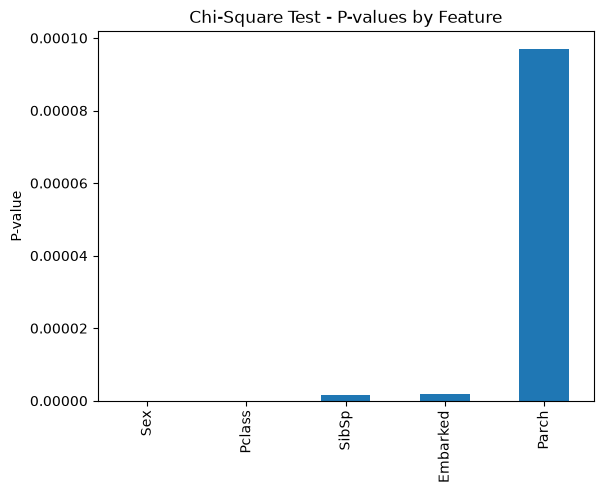

In [30]:
score = []

for feature in titanic.columns[:-1]:
    ct = pd.crosstab(titanic['Survived'], titanic[feature])
    p_value = chi2_contingency(ct)[1]
    score.append(p_value)

pd.Series(score, index=titanic.columns[:-1]).sort_values(ascending=True).plot(kind='bar')
plt.ylabel("P-value")
plt.title("Chi-Square Test - P-values by Feature")
plt.show()

### Chi-Square via sklearn (Encoded Features)

sklearn's `chi2` function offers a more integrated way to run this within a feature-selection pipeline — requires encoding categorical variables to numeric first.

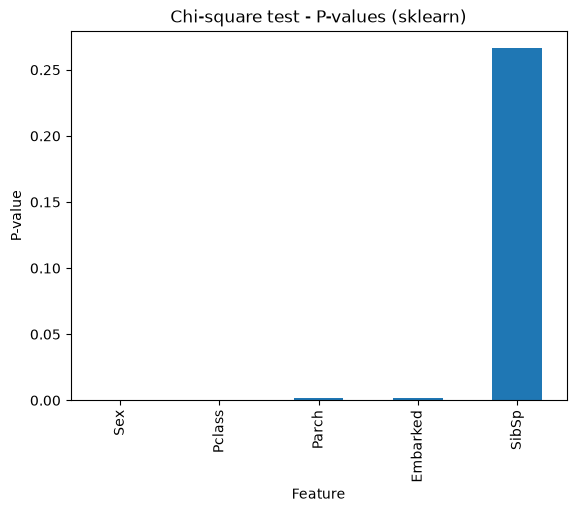

In [31]:
le = LabelEncoder()
titanic_encoded = titanic.apply(le.fit_transform)

X_titanic = titanic_encoded.drop('Survived', axis=1)
y_titanic = titanic_encoded['Survived']

chi_scores = chi2(X_titanic, y_titanic)

p_values = pd.Series(chi_scores[1], index=X_titanic.columns)
p_values.sort_values(inplace=True)

p_values.plot.bar()
plt.title('Chi-square test - P-values (sklearn)')
plt.xlabel('Feature')
plt.ylabel('P-value')
plt.show()

## Summary

This notebook covered five filter-based feature selection techniques:

1. **Variance Threshold** — removes low-variance (near-constant) features.
2. **Correlation with Target** — ranks numeric features by linear correlation with the target.
3. **ANOVA F-test** — tests whether numeric feature means differ significantly across target classes.
4. **Mutual Information** — captures both linear and non-linear dependence between feature and target.
5. **Chi-Square Test** — tests independence between categorical features and the target (via `chi2_contingency` and sklearn's `chi2`).

**Key takeaway:** On the Titanic dataset, `Sex` and `Pclass` consistently showed the strongest relationship with `Survived`, while `Parch` and `SibSp` were the weakest — consistent across both the manual chi-square test and sklearn's implementation.